In [ ]:
import pandas as pd
import numpy as np  
import matplotlib.pyplot as plt
import seaborn as sns

# Charts in Jupyter Notebook
%matplotlib inline
sns.set_theme(style="whitegrid")

## Loading the dataset
url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [14]:
# TotalCharges is a numeric column, but it is being read as an object due to the presence of spaces in some rows. We need to convert it to numeric and handle any errors.
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for any NaN values after conversion
isNull = df['TotalCharges'].isna().sum()
print(f"Number of NaN values in 'TotalCharges' after conversion: {isNull}")


df['TotalCharges'].dtype

Number of NaN values in 'TotalCharges' after conversion: 0


dtype('float64')

In [15]:
# Crpsstab between Churn and Contract

contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn 

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


In [17]:
# Crosstab between Churn and PaymentMethod
payment_churn = pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index') * 100
payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


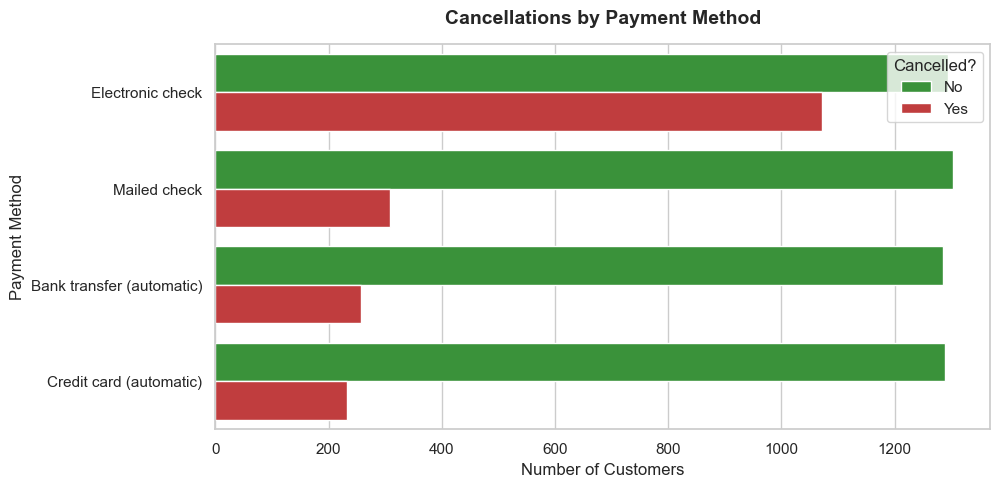

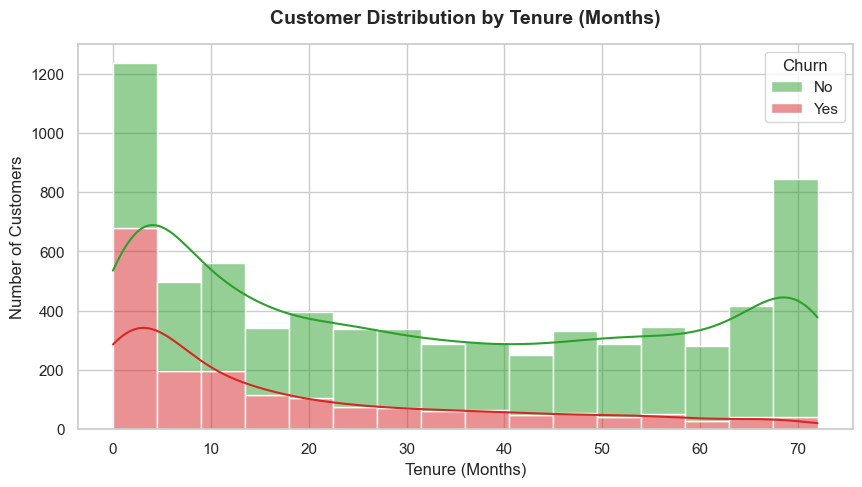

In [21]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='PaymentMethod', hue='Churn', palette=['#2ca02c', '#d62728'])

plt.title('Cancellations by Payment Method', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Number of Customers', fontsize=12)
plt.ylabel('Payment Method', fontsize=12)
plt.legend(title='Cancelled?')
plt.show()

plt.figure(figsize=(10, 5))
# Plotting the distribution of tenure for clients who left vs clients who stayed
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack', palette=['#2ca02c', '#d62728'], kde=True)

plt.title('Customer Distribution by Tenure (Months)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Tenure (Months)', fontsize=12)
plt.ylabel('Number of Customers', fontsize=12)
plt.show()

---

##  Findings from the Exploratory Data Analysis (EDA)

We have completed the first stage of the project, which involved understanding customer behaviour. We have identified the three main risk factors for churn:

1. **Tenure:** The risk is critical during the first few months of the contract (the customer onboarding phase), when the highest volume of cancellations occurs.
2. **Contract Type:** Customers on **month-to-month** contracts have an alarming cancellation rate of **~42.7%**.
3. **Payment Method:** The use of **Electronic Cheques** leads to the highest number of cancellations, reaching **~45%** churn.

###  Next Section: Pre-processing and Machine Learning
With the business bottlenecks mapped out, we will convert the textual variables into numbers so that the machine learning algorithms can learn these patterns and predict which customers are about to churn.

---


In [24]:
df['churn_numeric'] = df['Churn'].map({'No': 0, 'Yes': 1})
df[['Churn', 'churn_numeric']].head()

,Churn,churn_numeric
0,No,0
1,No,0
2,Yes,1
3,No,0
4,Yes,1


In [26]:
# Select the features for correlation analysis
features = ['tenure', 'Contract', 'PaymentMethod', 'churn_numeric']
df_model = df[features].copy()
df_model = pd.get_dummies(df_model, columns=['Contract', 'PaymentMethod'], drop_first=True)

df_model.head()

,tenure,churn_numeric,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,False,False,False,True,False
1,34,0,True,False,False,False,True
2,2,1,False,False,False,False,True
3,45,0,True,False,False,False,False
4,2,1,False,False,False,True,False


In [28]:
from sklearn.model_selection import train_test_split

#Separete explanatory variables and target variable
X = df_model.drop(columns=['churn_numeric'])
y = df_model['churn_numeric']

#Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

#Show the shape of the training and testing sets
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (5634, 6), (5634,)
Testing set shape: (1409, 6), (1409,)


In [30]:
from sklearn.linear_model import LogisticRegression

#Initialize the Machine Learning model
model = LogisticRegression(random_state=42)

#Train the model on the training set
model.fit(X_train, y_train)

#Show
print("Model training completed.")

Model training completed.


In [31]:
from sklearn.metrics import accuracy_score, classification_report

#Ask the model to predict the target variable for the testing set
y_pred = model.predict(X_test)

#Calculate and display the overall accuracy of the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

#Display a detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.76

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.89      0.85      1035
           1       0.57      0.42      0.48       374

    accuracy                           0.76      1409
   macro avg       0.69      0.65      0.66      1409
weighted avg       0.74      0.76      0.75      1409



---

# 🛠️ Step 2: Model Optimisation (Next Steps)

##  Analysis of Version 1.0
Our first model (Baseline) achieved an overall accuracy of **76%**. However, upon analysing the classification report, we identified a critical bottleneck for the business:
* The model has a **recall of just 42% for class 1 (Churn)**. This means it misses more than half of the customers who will cancel, failing to meet the project’s main objective.

##  Improvement Strategy (To be carried out in the next session)
To address the lack of sensitivity to cancellation cases, we will implement the following steps:

1. **Feature Engineering:** Inclusion of the `MonthlyCharges` variable (monthly bill amount) to provide the algorithm with the customer’s financial context.
2. **Imbalance Handling:** Use of the parameter `class_weight=“balanced”` in Logistic Regression to force the model to pay more attention to rare cases of churn.

---